# DL_Demonstration — Checkpoint 7

Демонстрация использования финальной модели без обучения:
- загружаем зарегистрированную модель из MLflow (`PRD`),
- подготавливаем вход,
- выполняем инференс и интерпретируем результат.


In [1]:
import os
import json
import base64
from io import BytesIO
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import mlflow
from mlflow import MlflowClient

TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
mlflow.set_tracking_uri(TRACKING_URI)
client = MlflowClient()

prd_ref_path = Path("results/checkpoint7/prd_reference.json")
if prd_ref_path.exists():
    prd_ref = json.loads(prd_ref_path.read_text(encoding="utf-8"))
else:
    prd_ref = {}

MODEL_NAME = os.environ.get("MLFLOW_MODEL_NAME", prd_ref.get("model_name", "flux_attention_research"))
MODEL_ALIAS = os.environ.get("MLFLOW_MODEL_ALIAS", "PRD")

print({
    "tracking_uri": TRACKING_URI,
    "model_name": MODEL_NAME,
    "model_alias": MODEL_ALIAS,
    "prd_ref_exists": prd_ref_path.exists(),
})

if prd_ref:
    print("PRD reference:")
    print(json.dumps(prd_ref, ensure_ascii=False, indent=2))
else:
    print("[warn] results/checkpoint7/prd_reference.json is missing; will try Model Registry alias directly")



{'tracking_uri': 'http://127.0.0.1:5000', 'model_name': 'flux_attention_research', 'model_alias': 'PRD', 'prd_ref_exists': True}


In [2]:
candidate_uris = []
if MODEL_NAME:
    candidate_uris.append(f"models:/{MODEL_NAME}@{MODEL_ALIAS}")
if prd_ref.get("prd_uri"):
    candidate_uris.append(prd_ref["prd_uri"])
if prd_ref.get("artifact_model_uri"):
    candidate_uris.append(prd_ref["artifact_model_uri"])

loaded_model = None
used_uri = None
for uri in candidate_uris:
    try:
        loaded_model = mlflow.pyfunc.load_model(uri)
        used_uri = uri
        break
    except Exception as e:
        print("[warn] cannot load", uri, "->", e)

if loaded_model is None:
    raise RuntimeError("Failed to load PRD model from all candidate URIs")

print("Loaded model URI:", used_uri)
if "@PRD" not in str(used_uri):
    print("[info] Loaded by fallback URI; PRD alias may be unavailable in this tracking server session")



Loaded model URI: models:/flux_attention_research@PRD


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You set `add_prefix_space`. The tokenizer needs to be converted from the slow tokenizers


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

,prompt,seed,image_base64
0,a watercolor portrait of a fox in autumn park,73,iVBORw0KGgoAAAANSUhEUgAAAwAAAAMACAIAAAAc45fZAA...


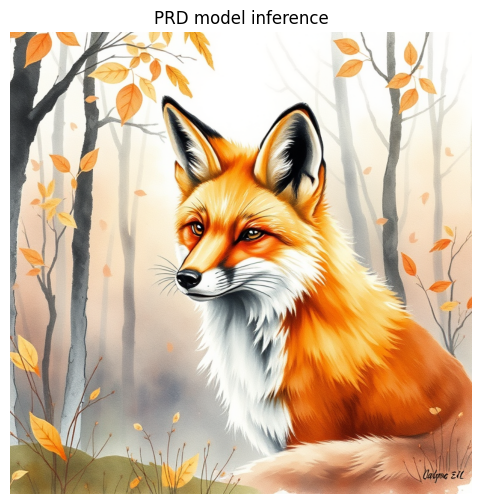

In [3]:
# Тестовый предикт
demo_input = pd.DataFrame([
    {"prompt": "a watercolor portrait of a fox in autumn park", "seed": 73},
])

pred_df = loaded_model.predict(demo_input)
display(pred_df.head())

if "image_base64" not in pred_df.columns:
    raise RuntimeError("Expected image_base64 in prediction output")

b = base64.b64decode(pred_df.iloc[0]["image_base64"])
img = Image.open(BytesIO(b)).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("PRD model inference")
plt.show()

## Интерпретация результата

- Загружена именно зарегистрированная версия модели из MLflow (`PRD` alias или fallback URI).
- Инференс выполнен без переобучения, что соответствует требованиям демонстрационного блока.
- Для отчета можно дополнительно показать 2-3 разных промпта с кратким сравнительным комментарием.
